In [29]:
# =============================================
# CELL 1: Upload Dataset ke Google Colab
# =============================================
from google.colab import files
print("Silakan unggah file 'berlin52.xlsx' :")
uploaded = files.upload()

Silakan unggah file 'berlin52.xlsx' :


Saving berlin52.xlsx to berlin52 (3).xlsx


In [30]:
# =============================================
# CELL 2: Import Library
# =============================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random
import csv
import time
%matplotlib inline
print('Library berhasil diimport.')

Library berhasil diimport.


## 1. Load Dataset
Membaca koordinat kota Berlin52 dari file Excel `berlin52.xlsx` yang telah diunggah.

In [31]:
def load_dataset(file_path):
    df = pd.read_excel(file_path)
    coords = df[['X', 'Y']].values
    cities = df['City'].values
    print(f"Berhasil memuat {len(df)} kota dari {file_path}")
    return df, coords, cities

df_cities, coords, city_ids = load_dataset('berlin52.xlsx')
df_cities.head()

Berhasil memuat 52 kota dari berlin52.xlsx


,City,X,Y
0,1,565,575
1,2,25,185
2,3,345,750
3,4,945,685
4,5,845,655


## 2. Hitung Matriks Jarak
Menghitung matriks jarak Euclidean antar semua pasangan kota (52×52).

In [32]:
def hitung_jarak(coords):
    n = len(coords)
    dist_matrix = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            if i != j:
                dist_matrix[i, j] = np.linalg.norm(coords[i] - coords[j])
    return dist_matrix

distance_matrix = hitung_jarak(coords)
print("Matriks jarak berhasil dihitung, dimensi:", distance_matrix.shape)

Matriks jarak berhasil dihitung, dimensi: (52, 52)


## 3. Parameter ACO

In [33]:
import random
import numpy as np

# Parameter Algoritma ACO
alpha        = 1    # Pengaruh pheromone (τ)
beta         = 2    # Pengaruh visibilitas/jarak (η)
rho          = 0.1  # Koefisien penguapan pheromone
n_ants       = 100  # Jumlah semut
n_iterations = 100   # Jumlah iterasi

# Seed agar hasil reprodusibel (hanya untuk numpy, random akan sepenuhnya acak)
np.random.seed(42)

print(f"Parameter: alpha={alpha}, beta={beta}, rho={rho}, semut={n_ants}, iterasi={n_iterations}")

Parameter: alpha=1, beta=2, rho=0.1, semut=100, iterasi=100


## 4. Helper Functions
- `roulette_wheel_selection` — Memilih kota berdasarkan probabilitas dengan roda roulette
- `update_pheromone` — Memperbarui pheromone setelah **setiap 1 semut** selesai berjalan (update sekuensial/online)

In [34]:
def roulette_wheel_selection(probabilities, r_val=None):
    """Roulette wheel selection. Mengembalikan (index, nilai_r)."""
    if r_val is None:
        r_val = random.random()
    cumulative = 0.0
    for idx, p in enumerate(probabilities):
        cumulative += p
        if r_val <= cumulative:
            return idx, r_val
    return len(probabilities) - 1, r_val


def update_pheromone(pheromone, tour, L_k, rho):
    """Update pheromone setelah 1 semut: evaporasi global + deposit delta_tau = 1/L_k."""
    pheromone = (1.0 - rho) * pheromone
    deposit = 1.0 / L_k
    for i in range(len(tour) - 1):
        u, v = tour[i], tour[i+1]
        pheromone[u, v] += deposit
        pheromone[v, u] += deposit
    return pheromone


print('Helper functions berhasil didefinisikan.')

Helper functions berhasil didefinisikan.


## 5. Loop Utama ACO + Tabel Keputusan Perpindahan Semut 1-100

**Cara kerja logging CSV:**
Untuk setiap semut pada **Iterasi 1**, program mencatat keputusan perpindahan di **4 langkah representatif**:
- **Step 1, 2, 3** → menunjukkan keputusan awal semut (dari mana → ke mana, berdasarkan R)
- **Step 52** → langkah kembali ke kota asal (rute penuh tersimpan di kolom Rute Sementara)

Total: **400 baris** untuk 100 semut (lebih ringkas dari 5.200 baris penuh).

In [35]:
# =============================================
# Inisialisasi output CSV
# =============================================
output_file = 'hasil_aco_berlin52.csv'
with open(output_file, 'w', newline='') as f:
    csv.writer(f).writerow([
        'Semut', 'Step', 'Dari Kota', 'Ke Kota',
        'Jarak', 'Pheromone', 'Probabilitas', 'Random R',
        'Keputusan', 'Rute Sementara'
    ])

# =============================================
# Inisialisasi variabel ACO
# =============================================
n_cities = len(coords)
pheromone = np.ones((n_cities, n_cities))
best_distance = float('inf')
best_tour = None
best_history = []
avg_history = []

start_time = time.time()

# =============================================
# MAIN ACO LOOP
# =============================================
for iteration in range(1, n_iterations + 1):
    tour_lengths = []

    for ant in range(n_ants):
        # Titik awal semut dipilih secara acak
        start   = random.randint(0, n_cities - 1)
        visited = [start]
        unvisited = set(range(n_cities))
        unvisited.remove(start)
        current = start

        transition_history = []
        is_first_iter = (iteration == 1)  # Hanya log detail di Iterasi 1

        # --- Perjalanan semut: kunjungi semua kota ---
        while unvisited:
            candidates = list(unvisited)
            scores = []
            for city in candidates:
                tau  = pheromone[current, city] ** alpha
                d    = distance_matrix[current, city]
                eta  = (1.0 / d) ** beta if d > 0 else 0
                scores.append(tau * eta)

            total = sum(scores)
            probabilities = [s / total for s in scores] if total > 0 else [1.0/len(candidates)] * len(candidates)

            r = random.random()
            chosen_idx, r_val = roulette_wheel_selection(probabilities, r)
            chosen_city = candidates[chosen_idx]

            if is_first_iter:
                transition_history.append({
                    'Step'        : len(visited),
                    'Dari Kota'   : current + 1,
                    'Ke Kota'     : chosen_city + 1,
                    'Jarak'       : distance_matrix[current, chosen_city],
                    'Pheromone'   : pheromone[current, chosen_city],
                    'Probabilitas': probabilities[chosen_idx],
                    'Random R'    : r_val,
                    'Keputusan'   : f'Pindah ke Kota {chosen_city + 1}'
                })

            visited.append(chosen_city)
            unvisited.remove(chosen_city)
            current = chosen_city

        # --- Kembali ke kota awal ---
        visited.append(start)

        # Hitung total jarak rute
        length = sum(distance_matrix[visited[i], visited[i+1]] for i in range(len(visited) - 1))

        if is_first_iter:
            transition_history.append({
                'Step'        : len(visited) - 1,
                'Dari Kota'   : current + 1,
                'Ke Kota'     : start + 1,
                'Jarak'       : distance_matrix[current, start],
                'Pheromone'   : pheromone[current, start],
                'Probabilitas': 1.0,
                'Random R'    : 0.0,
                'Keputusan'   : f'Kembali ke Awal (Kota {start + 1})'
            })

        # UPDATE PHEROMONE SETELAH 1 SEMUT SELESAI (Online/Sequential)
        pheromone = update_pheromone(pheromone, visited, length, rho)
        tour_lengths.append(length)

        if length < best_distance:
            best_distance = length
            best_tour     = visited[:]

        # --- Tulis ke CSV: hanya Step 1, 2, 3, dan 52 (ringkas tapi representatif) ---
        if is_first_iter:
            rows_to_write = [t for t in transition_history if t['Step'] in {1, 2, 3, 52}]
            with open(output_file, 'a', newline='') as f:
                w = csv.writer(f)
                for step_idx, t in enumerate(transition_history):
                    if t['Step'] not in {1, 2, 3, 52}:
                        continue
                    # Rute sementara: semua kota yang sudah dikunjungi sampai step ini
                    progress_idx = t['Step']  # step 1 = index 0→1, dst.
                    rute = '-'.join(str(c + 1) for c in visited[:progress_idx + 1])
                    w.writerow([
                        f'Semut {ant+1}',
                        t['Step'],
                        t['Dari Kota'],
                        t['Ke Kota'],
                        f"{t['Jarak']:.4f}",
                        f"{t['Pheromone']:.6f}",
                        f"{t['Probabilitas']:.6f}",
                        f"{t['Random R']:.6f}",
                        t['Keputusan'],
                        rute
                    ])

    best_history.append(best_distance)
    avg_history.append(float(np.mean(tour_lengths)))
    print(f'Iterasi {iteration:3d} | Best: {best_distance:,.2f} | Avg: {avg_history[-1]:,.2f}')

runtime = time.time() - start_time
print(f'\nSelesai dalam {runtime:.1f} detik')
print(f'Rute Terbaik : {[c+1 for c in best_tour]}')
print(f'Jarak Terpendek: {best_distance:.2f}')
print(f'CSV tersimpan : {output_file}')

Iterasi   1 | Best: 11,873.24 | Avg: 15,548.88
Iterasi   2 | Best: 8,795.73 | Avg: 10,721.71
Iterasi   3 | Best: 8,590.95 | Avg: 10,074.25
Iterasi   4 | Best: 8,173.76 | Avg: 9,964.19
Iterasi   5 | Best: 8,173.76 | Avg: 10,184.40
Iterasi   6 | Best: 8,173.76 | Avg: 10,004.28
Iterasi   7 | Best: 7,891.27 | Avg: 9,910.14
Iterasi   8 | Best: 7,792.57 | Avg: 9,779.59
Iterasi   9 | Best: 7,664.78 | Avg: 9,297.63
Iterasi  10 | Best: 7,664.78 | Avg: 9,469.51
Iterasi  11 | Best: 7,664.78 | Avg: 9,606.35
Iterasi  12 | Best: 7,664.78 | Avg: 9,803.48
Iterasi  13 | Best: 7,550.19 | Avg: 9,678.73
Iterasi  14 | Best: 7,550.19 | Avg: 9,585.81
Iterasi  15 | Best: 7,550.19 | Avg: 9,081.36
Iterasi  16 | Best: 7,550.19 | Avg: 9,200.85
Iterasi  17 | Best: 7,550.19 | Avg: 9,198.71
Iterasi  18 | Best: 7,550.19 | Avg: 9,381.69
Iterasi  19 | Best: 7,550.19 | Avg: 9,386.76
Iterasi  20 | Best: 7,550.19 | Avg: 9,570.26
Iterasi  21 | Best: 7,550.19 | Avg: 9,483.12
Iterasi  22 | Best: 7,550.19 | Avg: 9,517.62
Iter

## 6. Tampilkan Tabel Keputusan Perpindahan Semut 1-100
Menampilkan isi file `hasil_aco_berlin52.csv` — **Tabel Keputusan Perpindahan Kota** untuk seluruh 100 semut di Iterasi 1 (ringkas: 400 baris).

In [36]:
df_hasil = pd.read_csv('hasil_aco_berlin52.csv')
print(f'Total baris: {len(df_hasil)} | Kolom: {list(df_hasil.columns)}')
print(f'Semut: {df_hasil["Semut"].nunique()} semut unik\n')

# Tampilkan tabel interaktif (scroll)
pd.set_option('display.max_rows', 30)
pd.set_option('display.max_colwidth', 80)
display(df_hasil)

Total baris: 400 | Kolom: ['Semut', 'Step', 'Dari Kota', 'Ke Kota', 'Jarak', 'Pheromone', 'Probabilitas', 'Random R', 'Keputusan', 'Rute Sementara']
Semut: 100 semut unik



,Semut,Step,Dari Kota,Ke Kota,Jarak,Pheromone,Probabilitas,Random R,Keputusan,Rute Sementara
0,Semut 1,1,41,19,91.9239,1.000000,0.193249,0.574973,Pindah ke Kota 19,41-19
1,Semut 1,2,19,45,75.0000,1.000000,0.335115,0.617997,Pindah ke Kota 45,41-19-45
2,Semut 1,3,45,38,294.1088,1.000000,0.026680,0.762810,Pindah ke Kota 38,41-19-45-38
3,Semut 1,52,2,41,896.1724,1.000000,1.000000,0.000000,Kembali ke Awal (Kota 41),41-19-45-38-39-37-44-1-32-46-48-24-4-15-6-5-40-36-35-34-3-18-21-22-17-42-20-...
4,Semut 2,1,41,19,91.9239,0.900065,0.193260,0.611639,Pindah ke Kota 19,41-19
...,...,...,...,...,...,...,...,...,...,...
395,Semut 99,52,47,21,957.5490,0.000056,1.000000,0.000000,Kembali ke Awal (Kota 21),21-31-18-22-1-32-49-36-35-34-44-16-50-20-23-30-17-3-45-19-41-8-10-9-33-43-48...
396,Semut 100,1,46,44,130.8625,0.000313,0.248866,0.707339,Pindah ke Kota 44,46-44
397,Semut 100,2,44,35,96.1769,0.000075,0.073121,0.757953,Pindah ke Kota 35,46-44-35
398,Semut 100,3,35,36,15.0000,0.000628,0.662579,0.610419,Pindah ke Kota 36,46-44-35-36


## 7. Grafik Konvergensi per Iterasi
Dua kurva dalam satu grafik:
- **Biru** = Jarak terbaik (Best Distance) yang ditemukan sampai iterasi ke-i
- **Oranye** = Rata-rata jarak seluruh 100 semut di iterasi ke-i (menunjukkan konvergensi populasi)

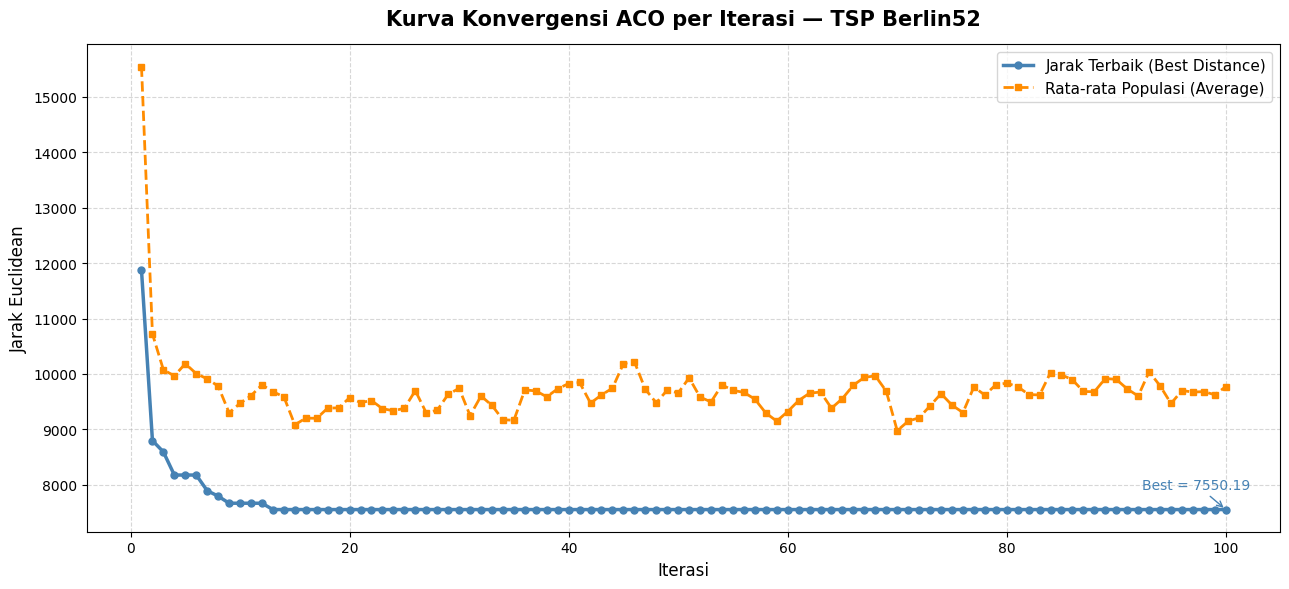

Grafik konvergensi disimpan: aco_convergence.png


In [37]:
fig, ax = plt.subplots(figsize=(13, 6))
iters = range(1, n_iterations + 1)

ax.plot(iters, best_history, color='steelblue', marker='o', linewidth=2.5,
        markersize=5, label='Jarak Terbaik (Best Distance)')
ax.plot(iters, avg_history,  color='darkorange', marker='s', linestyle='--',
        linewidth=2, markersize=4, label='Rata-rata Populasi (Average)')

ax.set_title('Kurva Konvergensi ACO per Iterasi — TSP Berlin52', fontsize=15, fontweight='bold', pad=14)
ax.set_xlabel('Iterasi', fontsize=12)
ax.set_ylabel('Jarak Euclidean', fontsize=12)
ax.grid(True, linestyle='--', alpha=0.5)
ax.legend(fontsize=11)
ax.annotate(f'Best = {best_distance:.2f}', xy=(n_iterations, best_history[-1]),
            xytext=(-60, 15), textcoords='offset points',
            arrowprops=dict(arrowstyle='->', color='steelblue'), fontsize=10, color='steelblue')

plt.tight_layout()
plt.savefig('aco_convergence.png', dpi=300, bbox_inches='tight')
plt.show()
print('Grafik konvergensi disimpan: aco_convergence.png')